## Example of the application of Ligextract

This example uses ligextract for the identification of all ligands in human RIPK1 and RIPK2. 
There are two possible applications for this: 

    1) Prepare molecular docking and/or;
    2) Enumerate known bound ligands

In [1]:
%%sh
echo "Q13546\nO43353" > ripk_uniprot_list.txt
cat ripk_uniprot_list.txt

Q13546
O43353


In [2]:
!ls

ligextract_selectligs_01.ipynb	ripk_uniprot_list.txt


#### I want all ligands for structures with minimal quality, so I will enforce a resolution cutoff of 3A. I will use the cleanup mode, to remove pdb files after the process ends (keeping just the original CIF files)

Run this line on the command line (with activated ligextract env):
    
    ligextract.sh -d ripk -r 3 -o cluster -c yes

accept all types of experiments, when prompted:

    Do you accept 'ELECTRON MICROSCOPY' entries (with 2 PDBs)? (type y/n) y
    Do you accept 'X-RAY DIFFRACTION' entries (with 55 PDBs)? (type y/n) y

In [4]:
!ls

cifprocessing.log		pdbs2download.txt
cifs				ripk
clusters			ripk_LIGS
ligand_extraction.log		ripk_pdb_uniprot_filteredlist.txt
ligextract_selectligs_01.ipynb	ripk_process_uniprot_chains.err
pdbconvert.log			ripk_process_uniprot_chains.txt
pdb_download.log		ripk_uniprot_list.txt


#### Read output and start processing ligands

In [72]:
import pandas as pd
import numpy as np
import py3Dmol

In [7]:
ligands = pd.read_csv("ripk_ligandsList.txt", sep="\t")
ligands

,ligandfile,pocketres_chain,pocketres_chain_size,chain_name,ligtype,lig_ID,pdbcode,original_ligID,chainUniprot,chainSize
0,5ar4_chain-A_lig-SB2-1311.pdb,ALA163-A;ALA28-A;ALA45-A;ARG26-A;ASN151-A;ASP1...,30,A,small-molecule ligand,SB2-1311,5ar4,SB2,A(O43353),A(309)
1,5ar4_chain-B_lig-SB2-1311.pdb,ALA163-B;ALA28-B;ALA45-B;ARG26-B;ASN151-B;ASP1...,27,B,small-molecule ligand,SB2-1311,5ar4,SB2,B(O43353),B(309)
2,24ic_chain-A_lig-01-301.pdb,ALA155-A;ASN143-A;ASP156-A;GLY158-A;HIS136-A;I...,26,A,small-molecule ligand,01-301,24ic,A1E6R,A(Q13546),A(293)
3,24ic_chain-B_lig-01-301.pdb,ALA155-B;ASP156-B;GLY158-B;GLY80-B;HIS136-B;IL...,28,B,small-molecule ligand,01-301,24ic,A1E6R,B(Q13546),B(293)
4,24ib_chain-A_lig-01-301.pdb,ALA155-A;ASN143-A;ASP156-A;ASP24-A;GLY158-A;HI...,28,A,small-molecule ligand,01-301,24ib,A1E6Q,A(Q13546),A(293)
...,...,...,...,...,...,...,...,...,...,...
96,9q31_chain-B_lig-TME-301.pdb,ALA231-B;ALA240-B;ARG246-B;ASN230-B;ASN245-B;A...,12,B,small-molecule ligand,TME-301,9q31,TME,B(Q13546),B(293)
97,9q32_chain-A_lig-01-301.pdb,ALA155-A;ASN143-A;ASN68-A;ASP156-A;GLY158-A;HI...,23,A,small-molecule ligand,01-301,9q32,A1CNV,A(Q13546),A(293)
98,9q32_chain-B_lig-01-301.pdb,ALA155-B;ASN143-B;ASN68-B;ASP156-B;GLY158-B;HI...,24,B,small-molecule ligand,01-301,9q32,A1CNV,B(Q13546),B(293)
99,9q32_chain-C_lig-01-301.pdb,ALA155-C;ASN143-C;ASN68-C;ASP156-C;GLY158-C;HI...,24,C,small-molecule ligand,01-301,9q32,A1CNV,C(Q13546),C(293)


In [8]:
ripk_uniprots_dict = {'Q13546':'ripk1', 'O43353':'ripk2'}

In [9]:
# there is one or two proteins to which each ligand is bound simultaneously
ligands.chainUniprot.unique()

array(['A(O43353)', 'B(O43353)', 'A(Q13546)', 'B(Q13546)',
       'A(P31947);B(O43353)', 'C(Q13546)', 'D(Q13546)'], dtype=object)

In [10]:
chain_unip_lst = []
for chains in ligands.chainUniprot.values:
    chain_unip = []
    for unip in ripk_uniprots_dict.keys():
        if unip in chains:
            chain_unip.append(ripk_uniprots_dict[unip])
    chain_unip_lst.append(";".join(chain_unip))

ligands.loc[:,"query"] = chain_unip_lst

In [11]:
ligands.value_counts(["query", "ligtype"])

query  ligtype              
ripk1  small-molecule ligand    64
ripk2  small-molecule ligand    37
Name: count, dtype: int64

#### only small ligands are found

In [12]:
prot_ligands = ligands.value_counts(["query", "original_ligID"], sort=False)
prot_ligands

query  original_ligID
ripk1  1HW               2
       1HX               3
       3CI               2
       3IF               2
       3IU               2
       65U               2
       7MJ               2
       A1BU4             2
       A1BU5             2
       A1BU6             2
       A1CNU             2
       A1CNV             4
       A1E6Q             2
       A1E6R             2
       A1IKX             1
       A1IPG             2
       A1IX7             1
       A1IX9             2
       EJP               4
       EJY               2
       GO4               2
       K8K               2
       L4Y               2
       L8D               2
       M5J               2
       O4U               2
       Q1A               2
       RCM               6
       TME               1
ripk2  0LI               2
       6GD               2
       6GE               2
       6IL               2
       9WS               2
       A1H90             2
       BW8               2
      

In [14]:
# unique ligand counts
prot_ligands["ripk1"].shape, prot_ligands["ripk2"].shape

((29,), (19,))

#### Now let's have a look at the clusters, focusing on ripk1 as example

In [15]:
!ls clusters

O43353_pocket_clusters_colorcodes.txt  Q13546_pocket_clusters_colorcodes.txt
O43353_pockets_hierarch-clusters.txt   Q13546_pockets_hierarch-clusters.txt


In [16]:
ripk_uniprots_dict

{'Q13546': 'ripk1', 'O43353': 'ripk2'}

In [17]:
q = 'Q13546'
clusters = pd.read_csv(f"clusters/{q}_pockets_hierarch-clusters.txt", sep="\t")
clusters.head()

,ligandfile,centroidX,centroidY,centroidZ,cluster,maxdist
0,24ic_chain-A_lig-01-301_aligned_LIG.pdb,-22.501,-5.571,-7.321,0,17.654
1,24ic_chain-B_lig-01-301_aligned_LIG.pdb,-22.853,-5.507,-7.222,0,17.654
2,24ib_chain-A_lig-01-301_aligned_LIG.pdb,-23.432,-5.410,-7.583,0,17.654
3,24ib_chain-B_lig-01-301_aligned_LIG.pdb,-23.514,-5.299,-7.718,0,17.654
4,4neu_chain-A_lig-Q1A-402_aligned_LIG.pdb,-21.763,-5.262,-9.078,0,17.654


In [19]:
clusters.value_counts("cluster")

cluster
0    63
1     1
Name: count, dtype: int64

only one meaningful cluster in ripk1 (0). We will focus on this cluster for the docking

In [21]:
cluster_ripk1 = clusters.query("cluster == 0")
cluster_ripk1.head()

,ligandfile,centroidX,centroidY,centroidZ,cluster,maxdist
0,24ic_chain-A_lig-01-301_aligned_LIG.pdb,-22.501,-5.571,-7.321,0,17.654
1,24ic_chain-B_lig-01-301_aligned_LIG.pdb,-22.853,-5.507,-7.222,0,17.654
2,24ib_chain-A_lig-01-301_aligned_LIG.pdb,-23.432,-5.410,-7.583,0,17.654
3,24ib_chain-B_lig-01-301_aligned_LIG.pdb,-23.514,-5.299,-7.718,0,17.654
4,4neu_chain-A_lig-Q1A-402_aligned_LIG.pdb,-21.763,-5.262,-9.078,0,17.654


#### Keep the first instance of each ligand in every pdb

In [22]:
ligands_ripk1 = ligands.drop_duplicates(["query", "pdbcode", "original_ligID"]).query("query == 'ripk1'")

In [23]:
ligands_ripk1.original_ligID.nunique(), ligands_ripk1.original_ligID.shape

(29, (32,))

In [24]:
alignedligs = [x.replace(".pdb", "_aligned_LIG.pdb") for x in ligands_ripk1.ligandfile]
ligands_ripk1.loc[:,"ligandfile_align"] = alignedligs

In [25]:
ligands_ripk1.shape, cluster_ripk1.shape

((32, 12), (63, 6))

In [26]:
cluster_ripk1 = cluster_ripk1.rename(columns = {"ligandfile":"ligandfile_align"})
cluster_ripk1.head()

,ligandfile_align,centroidX,centroidY,centroidZ,cluster,maxdist
0,24ic_chain-A_lig-01-301_aligned_LIG.pdb,-22.501,-5.571,-7.321,0,17.654
1,24ic_chain-B_lig-01-301_aligned_LIG.pdb,-22.853,-5.507,-7.222,0,17.654
2,24ib_chain-A_lig-01-301_aligned_LIG.pdb,-23.432,-5.410,-7.583,0,17.654
3,24ib_chain-B_lig-01-301_aligned_LIG.pdb,-23.514,-5.299,-7.718,0,17.654
4,4neu_chain-A_lig-Q1A-402_aligned_LIG.pdb,-21.763,-5.262,-9.078,0,17.654


In [27]:
cluster_ripk1_final = cluster_ripk1.merge(ligands_ripk1, on="ligandfile_align")

Confirm that the excluded ligand during the merge belonged to the other cluster

In [28]:
np.setdiff1d(ligands_ripk1.ligandfile, cluster_ripk1_final.ligandfile)

array(['9q31_chain-B_lig-TME-301.pdb'], dtype=object)

In [29]:
pd.read_csv(f"clusters/{q}_pockets_hierarch-clusters.txt", sep="\t").query("cluster == 1")

,ligandfile,centroidX,centroidY,centroidZ,cluster,maxdist
63,9q31_chain-B_lig-TME-301_aligned_LIG.pdb,-8.26,19.46,2.449,1,0.0


In [30]:
cluster_ripk1_final[["ligandfile_align", "pdbcode", "chain_name", "lig_ID", "original_ligID"]].to_csv("ripk1_cluster0_ligstodock.txt", sep="\t", index=False)

In [31]:
!head ripk1_cluster0_ligstodock.txt

ligandfile_align	pdbcode	chain_name	lig_ID	original_ligID
24ic_chain-A_lig-01-301_aligned_LIG.pdb	24ic	A	01-301	A1E6R
24ib_chain-A_lig-01-301_aligned_LIG.pdb	24ib	A	01-301	A1E6Q
4neu_chain-A_lig-Q1A-402_aligned_LIG.pdb	4neu	A	Q1A-402	Q1A
4iti_chain-A_lig-1HW-301_aligned_LIG.pdb	4iti	A	1HW-301	1HW
4itj_chain-A_lig-1HX-301_aligned_LIG.pdb	4itj	A	1HX-301	1HX
4ith_chain-A_lig-RCM-307_aligned_LIG.pdb	4ith	A	RCM-307	RCM
5hx6_chain-A_lig-65U-301_aligned_LIG.pdb	5hx6	A	65U-301	65U
5tx5_chain-A_lig-7MJ-301_aligned_LIG.pdb	5tx5	A	7MJ-301	7MJ
6c3e_chain-A_lig-EJY-301_aligned_LIG.pdb	6c3e	A	EJY-301	EJY


### Detect the cavity that overlaps the main cluster of ligands

This step needs a CAVIAR env present on the machine (see https://jr-marchand.github.io/caviar/using-caviar/installation)

Env installation command:

    conda create -n caviar -c jr-marchand caviar

In [32]:
from glob import glob
from biopandas.pdb import PandasPdb
from rdkit import Chem

In [33]:
!mkdir -p cavities

In [34]:
all_proteins = glob(f'ripk/pdbs_filtered_chains/{q}/aligned_pdbs/*_align.pdb')

In [35]:
filesdir = f"ripk/pdbs_filtered_chains/{q}/aligned_pdbs"
for pdb, ch in cluster_ripk1_final[["pdbcode", "chain_name"]].values:
    allchains=ch.replace(";","")
    pick_pdb_file = f'{filesdir}/{pdb}_keychain{allchains}_align.pdb'
    print(f"Running CAVIAR for protein {pick_pdb_file} (subcavities_only, allproteins)")
    cmd = f"caviar -code {pick_pdb_file.split('/')[-1]} -sourcedir {filesdir} -preset_config subcavities_only -out cavities -what allproteins -chain_id {allchains} > cavities/{pdb}_{allchains}_caviar_pocket.txt"
    ! source activate caviar; $cmd

Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/24ic_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/24ib_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/4neu_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/4iti_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/4itj_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/4ith_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/5hx6_keychainA_align.pdb (subcavities_only, allproteins)
Running CAVIAR for protein ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/5tx5_keychainA_al

In [36]:
!rm *.pml

In [38]:
!ls cavities | head

24ib_A_caviar_pocket.txt
24ib_keychainA_align_subcavs.pdb
24ic_A_caviar_pocket.txt
24ic_keychainA_align_subcavs.pdb
4ith_A_caviar_pocket.txt
4ith_keychainA_align_subcavs.pdb
4iti_A_caviar_pocket.txt
4iti_keychainA_align_subcavs.pdb
4itj_A_caviar_pocket.txt
4itj_keychainA_align_subcavs.pdb


In [39]:
!tail cavities/24ib_keychainA_align_subcavs.pdb

HETATM    1  N   SUB A   5     -13.289  -8.575  -8.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -8.575  -7.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -7.575 -10.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -7.575  -9.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -7.575  -8.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -7.575  -7.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -6.575 -10.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -6.575  -9.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -6.575  -8.281  1.00   1.00           N
HETATM    1  N   SUB A   5     -13.289  -6.575  -7.281  1.00   1.00           N


In [40]:
!cat cavities/24ib_A_caviar_pocket.txt

PDB_chain    CavID Ligab  Score  Size Hydrophob InterCh  AltLoc Miss  Subcavs 
24ib_keychainA_align_A   1    1.0    4.4   293     75%       0       0     0       5    
PDB_chain    CavID SubCavID Size Hydrophob. Polar  Neg   Pos  Other 
24ib_keychainA_align_A   1      1      44     73%      16%    0%    0%   11%  
24ib_keychainA_align_A   1      2      47     55%      45%    0%    0%    0%  
24ib_keychainA_align_A   1      3      41     78%      22%    0%    0%    0%  
24ib_keychainA_align_A   1      4      66     70%      15%    0%    0%   15%  
24ib_keychainA_align_A   1      5      95     87%      11%    0%    0%    2%  



In [41]:
cavities_coverage = []
for pocketfile in glob(f"cavities/*_caviar_pocket.txt"):
    #print(pocketfile)
    cavities_lst = open(pocketfile).read() #
    if "does not have a cavity" in cavities_lst: continue
    cavities_lst = cavities_lst.split("\nPDB_chain")[0].split("\n")
    cavities_lst = [x.strip().split() for x in cavities_lst]
    cavities_lst = pd.DataFrame(cavities_lst[1:], columns=cavities_lst[0])
    cavities_lst = cavities_lst.sort_values(["Ligab","Score"], ascending=False)
    for cavfile_ori, cav_idx, s in cavities_lst[["PDB_chain", "CavID","Size"]].values:
        cavfile = cavfile_ori.split("align")[0] + "align_subcavs.pdb"
        cavities_prot = PandasPdb().read_pdb(f'cavities/{cavfile}')
        cavities_id = cavities_prot.df["HETATM"].query("residue_name == 'SUB'").chain_id.drop_duplicates().values
        cav_id = cavities_id[int(cav_idx)-1]
        cav_bounds = cavities_prot.df["HETATM"].query(f"chain_id == '{cav_id}' and residue_name == 'SUB'")[["x_coord","y_coord", "z_coord"]].values
        buffer = 5
        max_bounds = cav_bounds.max(axis=0)+buffer
        min_bounds = cav_bounds.min(axis=0)-buffer
        #sanity check: print(cav_idx, cav_id, cav_bounds.shape[0], s)
        pdb = pocketfile.split("/")[-1].split("_")[0]
        #lig_centroid = cluster_ripk1_final.query(f"pdbcode == '{pdb}'")[['centroidX', 'centroidY', 'centroidZ']]
        ncoverage = 0
        for l, x,y,z in cluster_ripk1_final[["ligandfile_align",'centroidX', 'centroidY', 'centroidZ']].values:
            lig_centroid = np.array([x,y,z])
            if (lig_centroid<=max_bounds).all() and (lig_centroid>=min_bounds).all():
                ncoverage += 1
            #else:
            #    print(l, lig_centroid, max_bounds, min_bounds)
        cavities_coverage.append([cavfile_ori.split("align")[0]+"align.pdb", pdb, cav_idx, cav_id, ncoverage/cluster_ripk1_final.shape[0], ",".join(map(str,min_bounds.round(3))), ",".join(map(str,max_bounds.round(3)))])

In [42]:
cavities_coverage = pd.DataFrame(cavities_coverage, columns = ["pdbref","pdb", "cav_idx", "cavID", "n_covered", "mincoords", "maxcoords"])

#### inspect all cavities' boundaries

looks like there are two contiguous (overlapping) pockets per pdb (using the x axis as reference: one from -10ish to -20ish and another from -15ish to -30ish).

In [43]:
cavities_coverage.query("n_covered > 0")[0:10]

,pdbref,pdb,cav_idx,cavID,n_covered,mincoords,maxcoords
0,24ic_keychainA_align.pdb,24ic,1,A,1.000000,"-34.527,-15.742,-17.078","-8.527,7.258,4.922"
2,24ib_keychainA_align.pdb,24ib,1,A,1.000000,"-33.289,-15.575,-17.281","-8.289,7.425,1.719"
3,4neu_keychainA_align.pdb,4neu,1,A,1.000000,"-35.6,-14.008,-16.601","-6.6,6.992,0.399"
8,4iti_keychainA_align.pdb,4iti,1,A,0.935484,"-36.418,-14.131,-20.94","-18.418,7.869,-0.94"
10,4itj_keychainA_align.pdb,4itj,4,D,0.290323,"-23.419,-12.905,-14.976","-8.419,0.095,-0.976"
11,4itj_keychainA_align.pdb,4itj,1,A,0.935484,"-34.419,-13.905,-18.976","-18.419,8.095,-0.976"
17,4ith_keychainA_align.pdb,4ith,1,A,0.935484,"-34.256,-11.633,-17.265","-18.256,7.367,-1.265"
18,5hx6_keychainA_align.pdb,5hx6,1,A,1.000000,"-33.645,-15.757,-17.434","-6.645,7.243,3.566"
22,5tx5_keychainA_align.pdb,5tx5,1,A,1.000000,"-34.89,-15.223,-16.848","-6.89,6.777,4.152"
26,6c3e_keychainA_align.pdb,6c3e,1,A,0.935484,"-33.915,-12.574,-17.194","-17.915,7.426,-0.194"


To use the same box for every pdb, select from the full-coverage cavities

In [44]:
candidate_boxes = cavities_coverage.query("n_covered == 1")
candidate_boxes

,pdbref,pdb,cav_idx,cavID,n_covered,mincoords,maxcoords
0,24ic_keychainA_align.pdb,24ic,1,A,1.0,"-34.527,-15.742,-17.078","-8.527,7.258,4.922"
2,24ib_keychainA_align.pdb,24ib,1,A,1.0,"-33.289,-15.575,-17.281","-8.289,7.425,1.719"
3,4neu_keychainA_align.pdb,4neu,1,A,1.0,"-35.6,-14.008,-16.601","-6.6,6.992,0.399"
18,5hx6_keychainA_align.pdb,5hx6,1,A,1.0,"-33.645,-15.757,-17.434","-6.645,7.243,3.566"
22,5tx5_keychainA_align.pdb,5tx5,1,A,1.0,"-34.89,-15.223,-16.848","-6.89,6.777,4.152"
33,6nyh_keychainA_align.pdb,6nyh,1,A,1.0,"-34.55,-15.148,-18.0","-8.55,6.852,2.0"
41,6rln_keychainA_align.pdb,6rln,1,A,1.0,"-33.98,-14.993,-17.49","-8.98,7.007,1.51"
43,7fcz_keychainA_align.pdb,7fcz,1,A,1.0,"-34.186,-15.321,-17.252","-8.186,7.679,1.748"
45,7xmk_keychainA_align.pdb,7xmk,1,A,1.0,"-34.073,-13.511,-17.366","-9.073,6.489,1.634"
52,7fd0_keychainA_align.pdb,7fd0,1,A,1.0,"-33.856,-15.254,-17.845","-4.856,6.746,2.155"


In [45]:
#get a consensus box (max boundaries across all cavities)
boxmax = [list(eval(x)) for x in candidate_boxes.maxcoords.values]
boxmax = pd.DataFrame(boxmax).max()
boxmin = [list(eval(x)) for x in candidate_boxes.mincoords.values]
boxmin = pd.DataFrame(boxmin).min()

In [46]:
boxmax.values, boxmin.values

(array([-4.856,  8.212,  4.922]), array([-36.31 , -15.757, -18.866]))

### Docking with Gnina

you will need the gnina command enabled in your command line

In [49]:
#test gnina installation
#!gnina --help

In [50]:
xsize,ysize,zsize=boxsize
xcenter,ycenter,zcenter=boxcenter

#### Let's test with 24ic, chain A, (the first potein in the cavities table)

In [51]:
candidate_boxes[0:1]

,pdbref,pdb,cav_idx,cavID,n_covered,mincoords,maxcoords
0,24ic_keychainA_align.pdb,24ic,1,A,1.0,"-34.527,-15.742,-17.078","-8.527,7.258,4.922"


In [52]:
#pdbcalc = candidate_boxes[0:1].pdbref.values[0].split("_")[0]
#chaincalc = candidate_boxes[0:1].pdbref.values[0].split("keychain")[1].split("_")[0]
#pdbcalc, chaincalc
refstructure = candidate_boxes[0:1].pdbref.values[0]
refstructure

'24ic_keychainA_align.pdb'

In [53]:
print("tested ligands: ", len(cluster_ripk1_final.ligandfile_align.values))

tested ligands:  31


In [54]:
!ls ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/$refstructure

ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/24ic_keychainA_align.pdb


In [55]:
!mkdir -p docking
! cp ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/$refstructure docking/.
for l in cluster_ripk1_final.ligandfile_align.values:
    !cp ripk/pdbs_filtered_chains/Q13546/aligned_pdbs/$l docking/.

In [57]:
maindir=!pwd
maindir = maindir[0]

##### Prepare strutures (minimise)

In [61]:
# preparation of the protein with MOE (the prepared file ends with prot3d.pdb)

In [60]:
!ls $maindir/docking/*prot3d.pdb

/home/natalia/ripk/docking/24ic_keychainA_align_prot3d.pdb


In [65]:
# rebuild from smiles and minimise all ligands
smi_list = []
for lig in glob(f"{maindir}/docking/*_aligned_LIG.pdb"): 
    mol=Chem.MolFromPDBFile(lig)
    smi = Chem.MolToSmiles(mol)
    ligmin = lig.replace(".pdb", "_min.mol2")
    !obabel -:"$smi" -p 7.4 --gen3d --minimise --ff mmff94 -omol2 > $ligmin
    smi_list.append([lig,smi,mol])

1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 6
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 2 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 10 12
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted
1 molecule converted


#### Visual check of re-built structures versus original

In [100]:
idx = 15

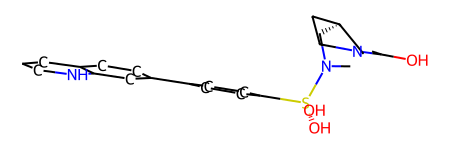

In [101]:
#ORIGINAL STRUCTURE
smi_list[idx][2]

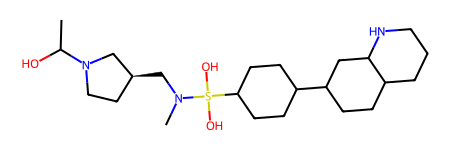

In [102]:
#REBUILT BACK FROM SMILES
Chem.MolFromSmiles(smi_list[idx][1])

In [69]:
prepstructure = refstructure.replace(".pdb", "_prot3d.pdb")
prepstructure

'24ic_keychainA_align_prot3d.pdb'

### Inspect prepared ligand and protein structures

In [73]:
ligidx = 0
xraylig = glob(f"{maindir}/docking/*_aligned_LIG.pdb")[ligidx]

v = py3Dmol.view()
v.addModel(open(f"{maindir}/docking/{prepstructure}").read(), 'pdb')
v.setStyle({'model': 0, 'not': {'elem':'H'}}, {'cartoon': {}, 'lines': {'radius': 0.1}}) # or stick to show residues

#para esconder a superfície, comentar a linha abaixo
v.addSurface(py3Dmol.SES,{'opacity':0.6,'color':'lightblue'})

v.addModel(open(xraylig).read(), 'pdb')
v.setStyle({'model': 1, 'not': {'elem':'H'}}, {'stick': {'colorscheme': 'coralCarbon', 'radius': 0.125}})

v.zoomTo({'model': 1})
v.rotate(90)
v.render()
v.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### Run the docking calculation (cross-docking against the selected structure and the first ligand on the list)

In [103]:
buff = 5
boxsize = (boxmax.values - boxmin.values)+buff
boxcenter = np.mean([boxmax.values, boxmin.values], axis=0)
boxsize, boxcenter

(array([36.454, 28.969, 28.788]), array([-20.583 ,  -3.7725,  -6.972 ]))

In [109]:
inputlig = glob(f"{maindir}/docking/24ic*_min.mol2")[0]
outputname = inputlig.replace(".mol2",".sdf")
!gnina -r $maindir/docking/$prepstructure -l $inputlig --center_x $xcenter --center_y $ycenter --center_z $zcenter --size_x $xsize --size_y $ysize --size_z $zsize --pose_sort_order CNNaffinity  -o $outputname --exhaustiveness 50 --num_modes 15 --min_rmsd_filter 1 --seed 0

              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.1 master:e4cb380+   Built Dec 18 2023.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Commandline: gnina -r /home/natalia/ripk/docking/24ic_keychainA_align_prot3d.pdb -l /home/natalia/ripk/docking/24ic_chain-A_lig-01-301_aligned_LIG_min.mol2 --center_x -20.583000000000002 --center_y -3.7725 --center_z -6.9719999999999995 --size_x 31.454 --size_y 23.969 --size_z 23.788 --pose_sort_order CNNaffinity -o /home/natalia/ripk/docking/24ic_chain-A_lig-01-301_aligned_LIG_min.sdf --exhaustiveness 50 --num_modes 15 --min_rmsd_filter 1 --seed 0
Using random seed: 0

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
***** | pose 0

In [112]:
xraylig = inputlig.replace("_min.mol2", ".pdb")
output_dock = inputlig.replace(".mol2",".sdf")
frame_id = 1   # Ranking of the pose to inspect, starting at 1

v = py3Dmol.view()
v.addModel(open(f"{maindir}/docking/{prepstructure}").read(), 'pdb')
v.setStyle({'model': 0, 'not': {'elem':'H'}}, {'cartoon': {}, 'linescoralCarbon': {'radius': 0.1}})

#para esconder a superfície, comentar a linha abaixo
v.addSurface(py3Dmol.SES,{'opacity':0.9,'color':'lightblue'})

v.addModel(open(xraylig).read(), 'pdb')
v.setStyle({'model': 1, 'not': {'elem':'H'}}, {'stick': {'colorscheme': 'dimgrayCarbon', 'radius': 0.125}})

v.addModelsAsFrames(open(output_dock).read(), 'sdf')
v.setStyle({'model': 2, 'not': {'elem':'H'}}, {'stick': {'colorscheme': 'greenCarbon'}})



v.setFrame(frame_id-1)
v.zoomTo({'model': 1})
v.rotate(90)
v.render()
v.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.